In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shashwatkumarjha/trainedweights/best.pt
/kaggle/input/datasets/shashwatkumarjha/chotudon/ChotiClip.mp4
/kaggle/input/datasets/abhinavbarman/hahahehe/hey buddy/test/labels/frame_000627.txt
/kaggle/input/datasets/abhinavbarman/hahahehe/hey buddy/test/labels/frame_000624.txt
/kaggle/input/datasets/abhinavbarman/hahahehe/hey buddy/test/labels/frame_000660.txt
/kaggle/input/datasets/abhinavbarman/hahahehe/hey buddy/test/labels/frame_000646.txt
/kaggle/input/datasets/abhinavbarman/hahahehe/hey buddy/test/labels/frame_000671.txt
/kaggle/input/datasets/abhinavbarman/hahahehe/hey buddy/test/labels/frame_000737.txt
/kaggle/input/datasets/abhinavbarman/hahahehe/hey buddy/test/labels/frame_000637.txt
/kaggle/input/datasets/abhinavbarman/hahahehe/hey buddy/test/labels/frame_000771.txt
/kaggle/input/datasets/abhinavbarman/hahahehe/hey buddy/test/labels/frame_000744.txt
/kaggle/input/datasets/abhinavbarman/hahahehe/hey buddy/test/labels/frame_000709.txt
/kaggle/input/datasets/a

In [2]:
!pip install ultralytics
!pip install boxmot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 4.6 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 32.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.3 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 49.5 MB/s eta 0:00:00
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=6dd8bc73660fc7c59a302ac725d5367604e1994a5121f4cec80e2ecd6c330fab
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy
  Attemptin

In [3]:
import os
import cv2
import numpy as np
import torch
import copy
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from boxmot import BotSort

# Disable W&B logging if you don't use it
os.environ['WANDB_DISABLED'] = 'true'

def create_video_writer(video_cap, output_filename):
    # Grab the width, height, and fps of the frames in the video stream.
    frame_width = int(video_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(video_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(video_cap.get(cv2.CAP_PROP_FPS))

    # Initialize the FourCC and a video writer object
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    writer = cv2.VideoWriter(output_filename, fourcc, fps, (frame_width, frame_height))

    return writer

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
import cv2
import numpy as np
import torch
import gc # Crucial for memory management
from pathlib import Path
from ultralytics import YOLO
from boxmot import BotSort
from collections import deque
import os

os.environ['WANDB_DISABLED'] = 'true'

# Initialize the tracker
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
tracker = BotSort(
    reid_weights=Path('osnet_x0_25_msmt17.pt'),  # which ReID model to use
    device=device,
    half=False
)

# Initialize YOLO
yolo_model = YOLO('/kaggle/input/datasets/shashwatkumarjha/trainedweights/best.pt')

# Double-check this path! Kaggle folders are often completely lowercase (e.g., /trimfin/)
input_video_path = '/kaggle/input/datasets/shashwatkumarjha/chotudon/ChotiClip.mp4'
vid = cv2.VideoCapture(input_video_path)

# FIX 1: Raise an error instead of killing the kernel!
if not vid.isOpened():
    raise FileNotFoundError(f"🚨 Could not open video at {input_video_path}. Check the DATASETS panel to see if the folder name is lowercase!")

output_video_path = '/kaggle/working/videoplayback_tracked.mp4'
# Assuming create_video_writer is defined in a previous cell
out = create_video_writer(vid, output_video_path)

frame_count = 1000
counter = 0

trail_path = {0:{}, 1:{}, 2:{}, 3:{}, 4:{}, 5:{}, 6:{}, 7:{}, 8:{}, 9:{}, 10:{}, 'fc':[]}
counter_arr = {0:{}, 1:{}, 2:{}, 3:{}, 4:{}, 5:{}, 6:{}, 7:{}, 8:{}, 9:{}, 10:{}}

while frame_count > 0:
    counter += 1
    frame_count -= 1
    ret, im = vid.read()
    if not ret:
        trail_path['fc'].append(1000 - frame_count)
        break

    try:
        # FIX 2: Downscale frame size so it doesn't crash the GPU memory
        results = yolo_model(im, imgsz=640)

        # Convert the detections: N X (x, y, x, y, conf, cls)
        dets = []
        for result in results:
            for detection in result.boxes.data.cpu().numpy():
                x1, y1, x2, y2, conf, cls = detection
                dets.append([x1, y1, x2, y2, conf, int(cls)])
        dets = np.array(dets)

        # Update tracker with detections
        tracker.update(dets, im)
        for a in tracker.active_tracks:
            if a.history_observations.maxlen == 50:
                a.history_observations = deque(a.history_observations, maxlen=1000)

        tracker.plot_results(im, show_trajectories=True)

        # Record trail history
        for a in tracker.active_tracks:
            if len(a.history_observations) > 2:
                trail_path[a.cls][a.id] = a.history_observations
                
                if counter not in counter_arr[a.cls].get(a.id, []):
                    if a.id not in counter_arr[a.cls]:
                        counter_arr[a.cls][a.id] = []
                    counter_arr[a.cls][a.id].append(counter)

        # Write frame to video
        out.write(im)

        # FIX 3: Empty the trash!
        del results
        del dets
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as e:
        print(f"An error occurred: {e}")
        break

vid.release()
out.release()
cv2.destroyAllWindows()

print(f"Tracking video saved to {output_video_path}")

SUCCESS  | BotSort: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, track_high_thresh=0.5, track_low_thresh=0.1, new_track_thresh=0.6, track_buffer=30, match_thresh=0.8, proximity_thresh=0.5, appearance_thresh=0.25, cmc_method=ecc, frame_rate=30, fuse_first_associate=False, with_reid=True
INFO     | BoxMOT v16.0.10 🚀 Python-3.12.12 torch-2.9.0+cu126
CUDA:0 (Tesla T4, 14913MiB)
INFO     | osnet_x0_25_msmt17.pt
INFO     | [PID 55] Downloading ReID weights from https://drive.google.com/uc?id=1sSwXSUlj4_tHZequ_iZ8w_Jh0VaRQMqF → osnet_x0_25_msmt17.pt
Downloading...
From: https://drive.google.com/uc?id=1sSwXSUlj4_tHZequ_iZ8w_Jh0VaRQMqF
To: /kaggle/working/osnet_x0_25_msmt17.pt
100%|██████████| 3.06M/3.06M [00:00<00:00, 194MB/s]
SUCCESS  | Loaded pretrained weights from osnet_x0_25_msmt17.pt
OpenCV: FFMPEG: tag 0x44495658/'XVID' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0


0: 384x640 10 cars, 4 2wheelers, 108.6ms
Speed: 13.5ms preprocess, 108.6ms inference, 46.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 cars, 1 person, 2 2wheelers, 25.3ms
Speed: 2.5ms preprocess, 25.3ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 cars, 1 person, 2 2wheelers, 25.3ms
Speed: 3.2ms preprocess, 25.3ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 cars, 3 2wheelers, 25.3ms
Speed: 2.5ms preprocess, 25.3ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 cars, 2 2wheelers, 25.4ms
Speed: 3.3ms preprocess, 25.4ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 cars, 1 person, 3 2wheelers, 25.3ms
Speed: 2.6ms preprocess, 25.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 cars, 2 persons, 3 2wheelers, 25.3ms
Speed: 2.5ms preprocess, 25.3ms inference, 1.3ms postprocess per image at shape (1, 3, 3

In [7]:
import copy

def path_process(trail_path_dict):
    # Safely remove the frame count array
    fc = trail_path_dict.pop('fc', [])
    trail_path_cent_x = copy.deepcopy(trail_path_dict)
    trail_path_cent_y = copy.deepcopy(trail_path_dict)
    
    for cls in trail_path_dict.keys():
        if cls == 'fc':
            continue
        for k in trail_path_dict[cls].keys():
            for i in range(len(trail_path_dict[cls][k])):
                # Calculate center points: (x1 + x2)/2 and (y1 + y2)/2
                trail_path_cent_x[cls][k][i] = (trail_path_dict[cls][k][i][0] + trail_path_dict[cls][k][i][2]) / 2
                trail_path_cent_y[cls][k][i] = (trail_path_dict[cls][k][i][1] + trail_path_dict[cls][k][i][3]) / 2

    return trail_path_cent_x, trail_path_cent_y, fc

# Copy the data so we don't mess up the original, then process it
trail_path_2 = copy.deepcopy(trail_path)
x, y, fc = path_process(trail_path_2)

print("✅ Trajectories processed successfully!")

✅ Trajectories processed successfully!


/tmp/ipykernel_55/988139364.py:14: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


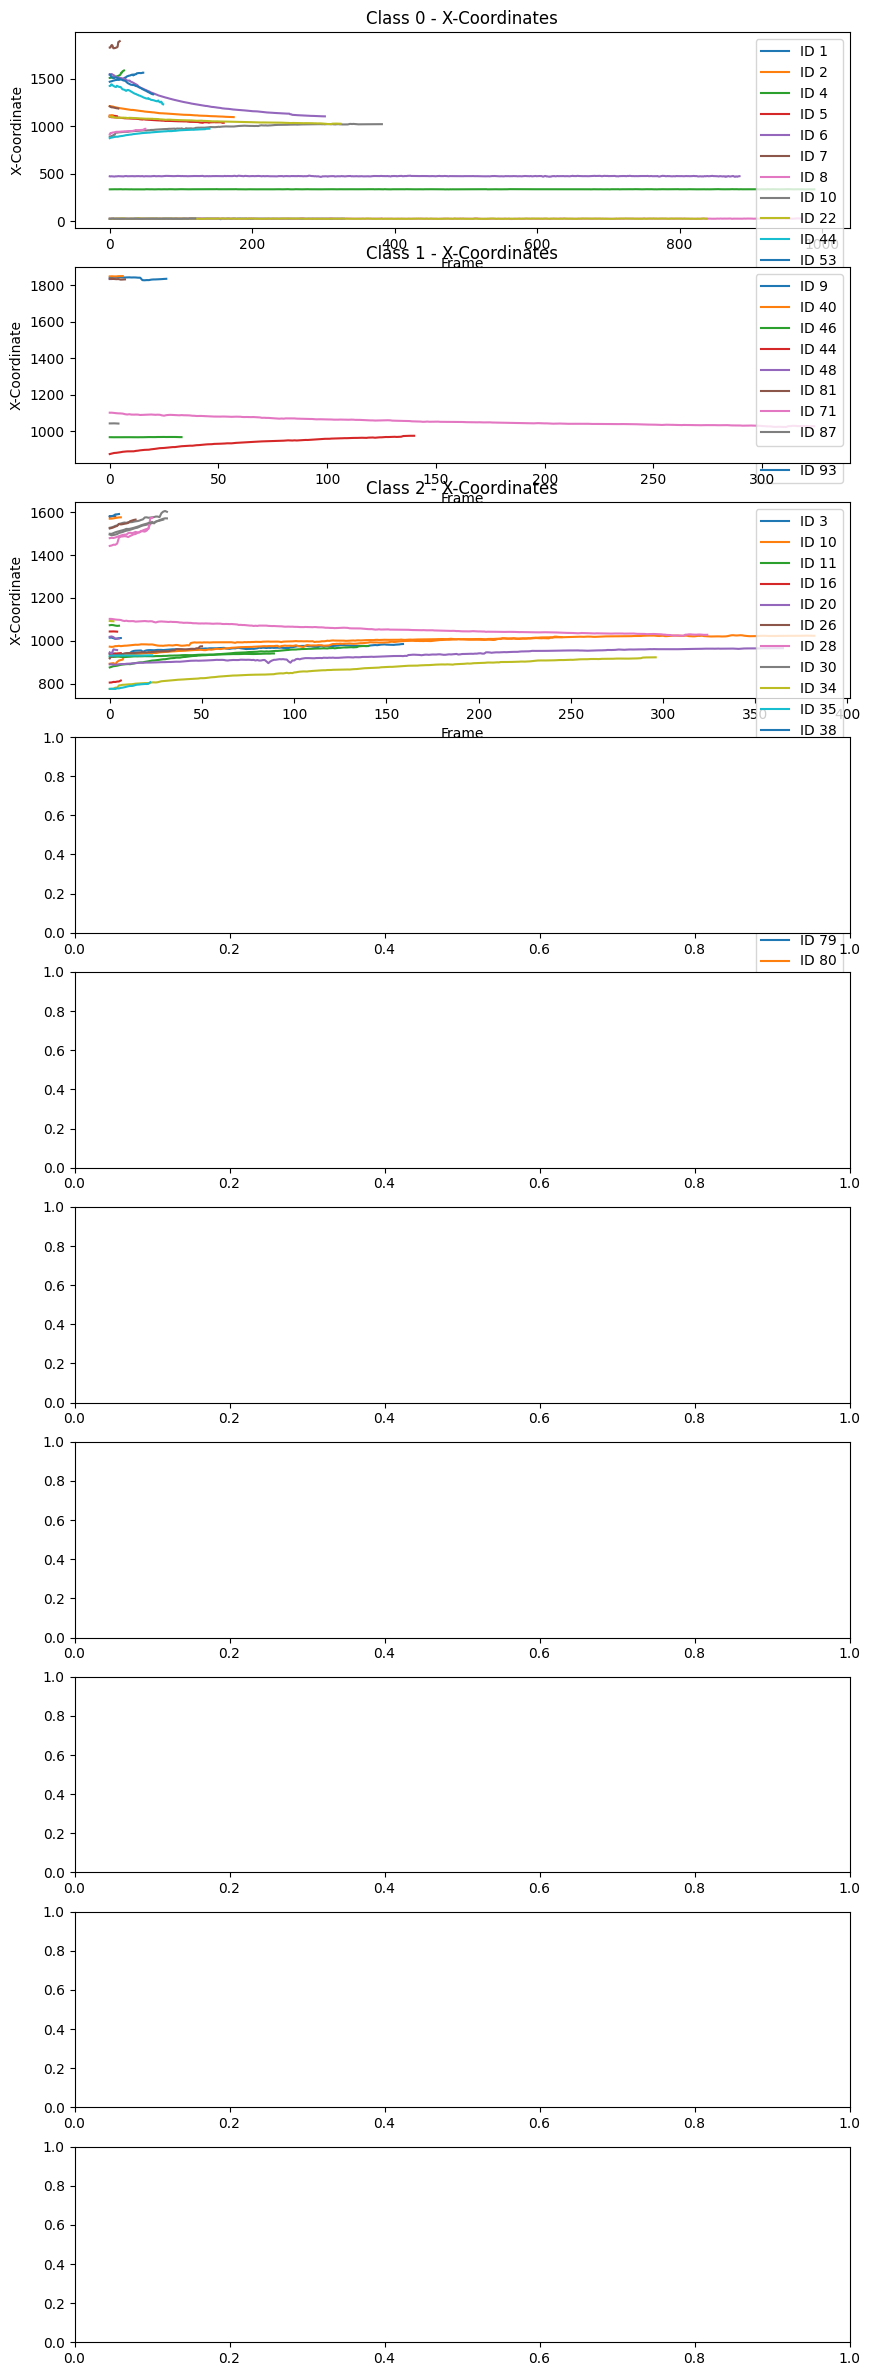

/tmp/ipykernel_55/988139364.py:28: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


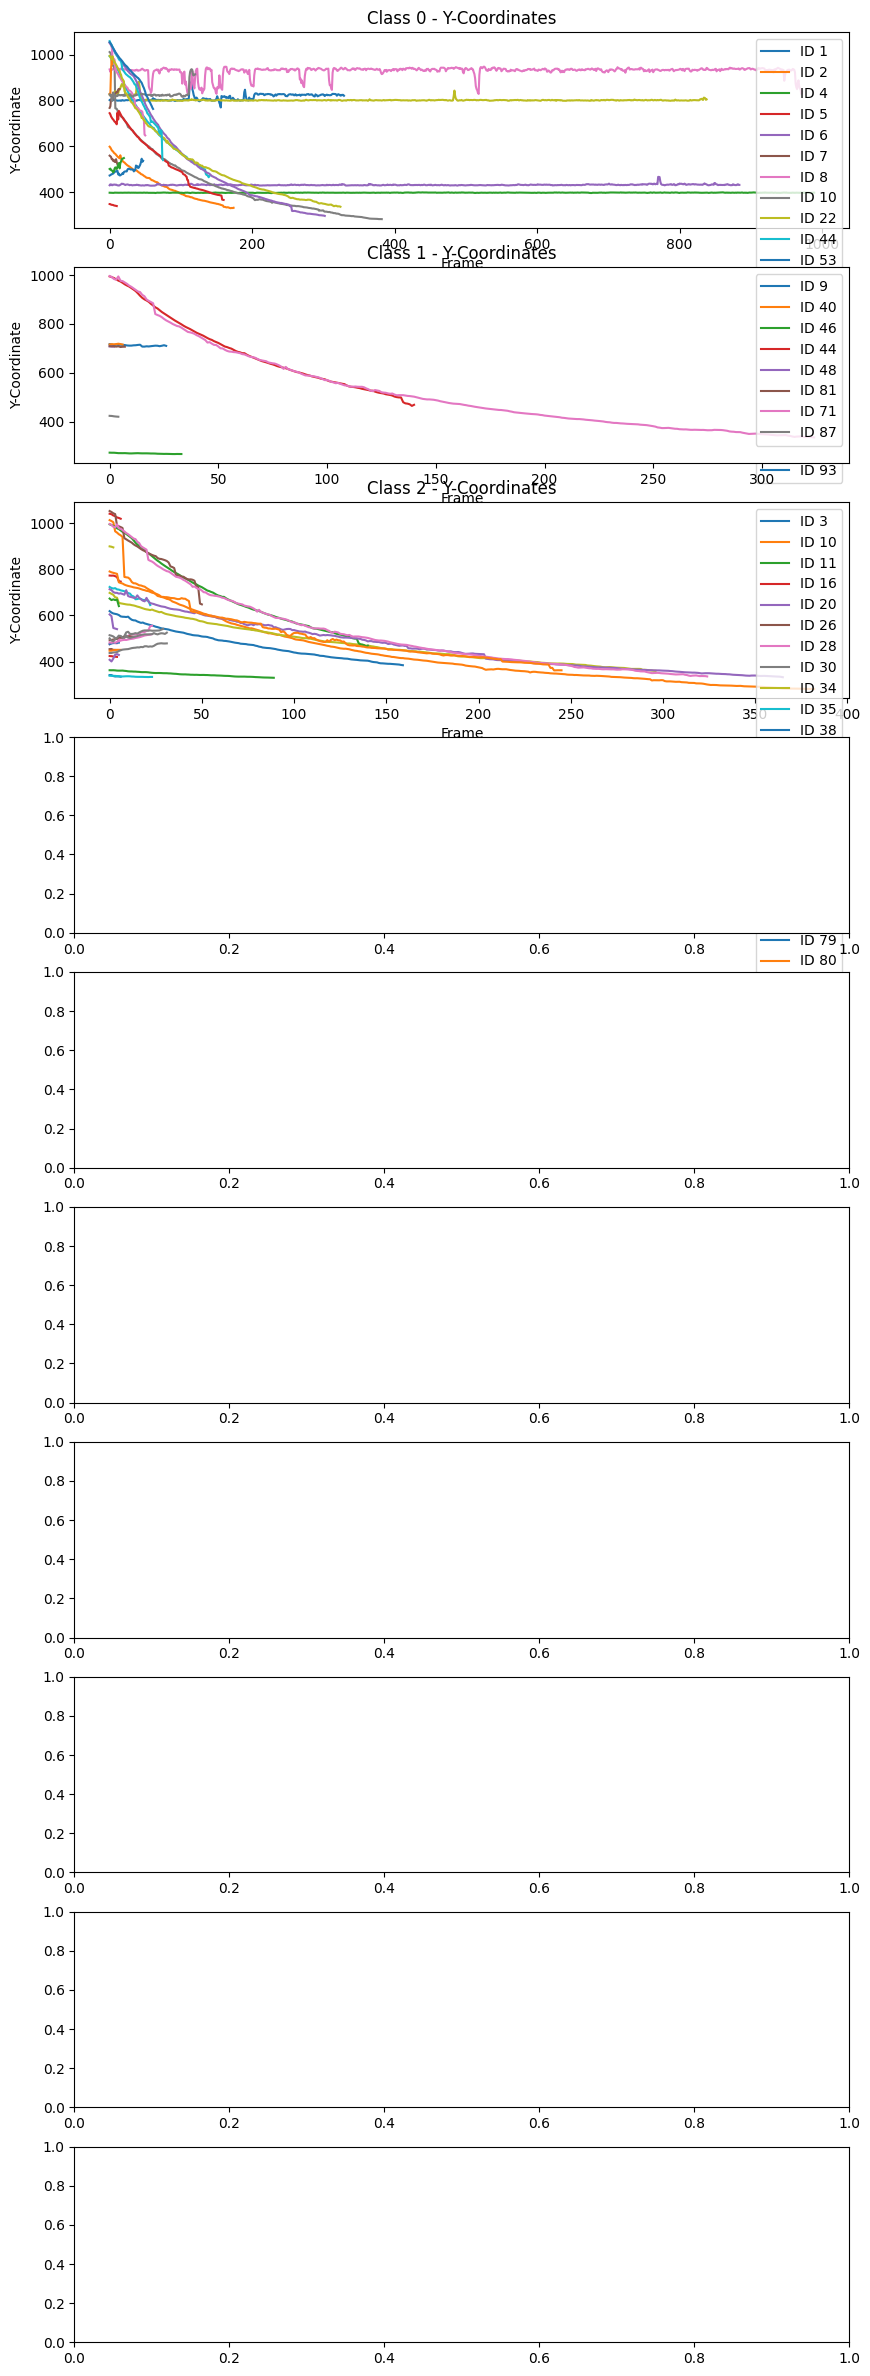

In [8]:
import matplotlib.pyplot as plt

# Plot X-Coordinates
fig_x, axes_x = plt.subplots(10, 1, figsize=(10, 30))
for cls in range(10):
    ax = axes_x[cls]
    if cls in x.keys() and x[cls]:
        for object_id in x[cls].keys():
            ax.plot(range(len(x[cls][object_id])), x[cls][object_id], label=f'ID {object_id}')
        ax.set_title(f'Class {cls} - X-Coordinates')
        ax.set_xlabel('Frame')
        ax.set_ylabel('X-Coordinate')
        ax.legend()
plt.tight_layout()
plt.show()

# Plot Y-Coordinates
fig_y, axes_y = plt.subplots(10, 1, figsize=(10, 30))
for cls in range(10):
    ax = axes_y[cls]
    if cls in y.keys() and y[cls]:
        for object_id in y[cls].keys():
            ax.plot(range(len(y[cls][object_id])), y[cls][object_id], label=f'ID {object_id}')
        ax.set_title(f'Class {cls} - Y-Coordinates')
        ax.set_xlabel('Frame')
        ax.set_ylabel('Y-Coordinate')
        ax.legend()
plt.tight_layout()
plt.show()

In [9]:
import os

output_dir = '/kaggle/working/'

for cls in range(10):
    output_filename = os.path.join(output_dir, f'output_class_{cls}.txt')

    # If class exists in x and y dictionaries
    if cls in x.keys() and cls in y.keys() and x[cls]:
         for object_id in x[cls].keys():
             if object_id in y[cls].keys():
                with open(output_filename, 'a') as file:
                    # Writing the X array, Y array, ID, and Frame Counter array
                    file.write(f"{x[cls][object_id]} {y[cls][object_id]} {object_id} {counter_arr[cls][object_id]}\n")

print("✅ Text files saved successfully to /kaggle/working/")

✅ Text files saved successfully to /kaggle/working/


In [13]:
from ultralytics import YOLO

# Load your repacked model
model = YOLO('/kaggle/input/datasets/shashwatkumarjha/trainedweights/best.pt')

# Print the dictionary of classes {ID: 'Name'}
print("Classes in model metadata:")
print(model.names)

Classes in model metadata:
{0: 'car', 1: 'person', 2: '2wheeler'}


In [11]:
%%writefile /kaggle/working/data.yaml

# Point to the IMAGES folder. YOLO will look for 'labels' automatically.
train: /kaggle/input/datasets/abhinavbarman/hahahehe/hey buddy/train/images
val: /kaggle/input/datasets/abhinavbarman/hahahehe/hey buddy/test/images

nc: 3
names: ['car','person','2wheeler']

Writing /kaggle/working/data.yaml


In [12]:

import os

# Define the path to the test folder
test_label_path = '/kaggle/input/datasets/abhinavbarman/hahahehe/hey buddy/test/labels'

# Check if a cache file exists in your working directory or input
# Note: Since input is read-only, YOLO usually puts the cache in /kaggle/working/
for root, dirs, files in os.walk('/kaggle/working'):
    for file in files:
        if file.endswith('.cache'):
            os.remove(os.path.join(root, file))
            print(f"Removed stale cache: {file}")

In [ ]:
import os

# Change this to the exact path you see in your Kaggle sidebar
img_path = '/kaggle/input/datasets/abhinavbarman/hahahehe/hey buddy/test/images'
lbl_path = '/kaggle/input/datasets/abhinavbarman/hahahehe/hey buddy/test/labels'

print(f"Images found: {len(os.listdir(img_path)) if os.path.exists(img_path) else 'FOLDER NOT FOUND'}")
print(f"Labels found: {len(os.listdir(lbl_path)) if os.path.exists(lbl_path) else 'FOLDER NOT FOUND'}")

In [ ]:
label_dir = '/kaggle/input/datasets/abhinavbarman/hahahehe/hey buddy/test/labels'
sample_file = os.listdir(label_dir)[0]
with open(os.path.join(label_dir, sample_file), 'r') as f:
    print(f"Contents of {sample_file}:")
    print(f.read())

In [ ]:
import os

# Search and destroy any .cache files in the working directory
for root, dirs, files in os.walk('/kaggle/working'):
    for file in files:
        if file.endswith('.cache'):
            os.remove(os.path.join(root, file))
            print(f"🗑️ Deleted stale cache: {file}")

In [ ]:
!cp -r "/kaggle/input/datasets/abhinavbarman/hahahehe/hey buddy" /kaggle/working/hey_buddy

In [ ]:
import os

label_dir = "/kaggle/working/hey_buddy/train/labels"

bad = []

for file in os.listdir(label_dir):
    
    with open(os.path.join(label_dir,file)) as f:
        for line in f:
            c,x,y,w,h = map(float,line.split())
            
            if (x-w/2 < 0) or (x+w/2 > 1) or (y-h/2 < 0) or (y+h/2 > 1):
                bad.append(file)
                break

print("Boxes outside image:", len(bad))
print(bad[:10])

In [ ]:
import os

label_dir = "/kaggle/working/hey_buddy/train/labels"

for file in os.listdir(label_dir):

    new_lines = []

    with open(os.path.join(label_dir,file)) as f:
        for line in f:
            c,x,y,w,h = map(float,line.split())

            x = min(max(x,0),1)
            y = min(max(y,0),1)

            if x-w/2 < 0:
                w = x*2
            if x+w/2 > 1:
                w = (1-x)*2
            if y-h/2 < 0:
                h = y*2
            if y+h/2 > 1:
                h = (1-y)*2

            new_lines.append(f"{int(c)} {x} {y} {w} {h}\n")

    with open(os.path.join(label_dir,file),"w") as f:
        f.writelines(new_lines)

print("Bounding boxes corrected")

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

# Load your weights
model = YOLO('/kaggle/input/datasets/shashwatkumarjha/trainedweights/best.pt') 

# Print the class names the model knows
print("Model classes:", model.names)

In [ ]:
import yaml

dataset_config = {
    'path': '/kaggle/working/chotudon', 
    'train': 'train/images',            
    'val': 'val/images',                
    'nc': 3,                            
    'names': ['car', 'person', '2wheeler'] # Updated to match your model exactly
}

with open('/kaggle/working/chotudon.yaml', 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False)

In [ ]:
import os

# Update this path to where your training .txt label files are located
label_dir = "/kaggle/working/hey_buddy/train/labels" # Or /kaggle/input/... path

unique_classes = set()

# Loop through all label files
for filename in os.listdir(label_dir):
    if filename.endswith('.txt'):
        with open(os.path.join(label_dir, filename), 'r') as f:
            for line in f:
                # The class ID is the first number in each line
                class_id = int(float(line.split()[0]))
                unique_classes.add(class_id)

print(f"Unique class IDs found in your dataset labels: {sorted(list(unique_classes))}")

In [ ]:
import os

# Define the directories containing your labels
# (Update these if your folders are named differently)
label_dirs = [
    '/kaggle/working/chotudon/train/labels', 
    '/kaggle/working/chotudon/val/labels'
]

# The classes we want to keep
allowed_classes = {0, 1, 2}

for label_dir in label_dirs:
    # Check if the folder exists to prevent errors
    if not os.path.exists(label_dir):
        print(f"Skipping: Directory not found - {label_dir}")
        continue
        
    cleaned_files_count = 0
    
    for filename in os.listdir(label_dir):
        if filename.endswith('.txt'):
            filepath = os.path.join(label_dir, filename)
            
            # Read the current bounding boxes
            with open(filepath, 'r') as f:
                lines = f.readlines()
                
            # Keep only the boxes that belong to classes 0, 1, or 2
            valid_lines = []
            for line in lines:
                parts = line.strip().split()
                if not parts: 
                    continue
                class_id = int(float(parts[0]))
                if class_id in allowed_classes:
                    valid_lines.append(line)
            
            # Overwrite the file with the filtered boxes
            with open(filepath, 'w') as f:
                f.writelines(valid_lines)
                cleaned_files_count += 1
                
    print(f"Cleaned {cleaned_files_count} files in {label_dir}")

print("Dataset cleaning complete! You are ready to train.")

In [ ]:
import os
import yaml

working_dataset = '/kaggle/working/hey_buddy_cleaned'

# Check if a dedicated 'val' folder exists; if not, fallback to 'test'
if os.path.exists(f'{working_dataset}/val/images'):
    val_path = f'{working_dataset}/val/images'
    print("Found 'val' directory.")
elif os.path.exists(f'{working_dataset}/test/images'):
    val_path = f'{working_dataset}/test/images'
    print("No 'val' directory found. Using 'test' directory for validation instead.")
else:
    # Extreme fallback just in case neither exist
    val_path = f'{working_dataset}/train/images' 
    print("Neither 'val' nor 'test' found. Falling back to 'train' for validation.")

# Generate the updated YAML
dataset_config = {
    'train': f'{working_dataset}/train/images',
    'val': val_path,  
    'nc': 3,
    'names': ['car', 'person', '2wheeler']
}

with open('/kaggle/working/chotudon.yaml', 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False)
    
print("✅ chotudon.yaml updated successfully! You can now start training.")

In [ ]:
!find /kaggle/working/ -name "best.pt"

In [ ]:
import os
import shutil
import yaml

# 1. Define paths
source_dataset = '/kaggle/input/datasets/abhinavbarman/hahahehe/hey buddy' 
working_dataset = '/kaggle/working/hey_buddy_cleaned'

# 2. Copy the dataset to the working directory
if os.path.exists(working_dataset):
    shutil.rmtree(working_dataset) 
shutil.copytree(source_dataset, working_dataset)
print("✅ Dataset copied back to working directory.")

# 3. Clean the labels in ALL splits (train, val, test)
allowed_classes = {0, 1, 2}
splits = ['train', 'val', 'test']

for split in splits:
    label_dir = os.path.join(working_dataset, split, 'labels')
    cache_path = os.path.join(working_dataset, split, 'labels.cache')
    
    if os.path.exists(cache_path):
        os.remove(cache_path)
        
    if not os.path.exists(label_dir):
        continue
        
    cleaned_count = 0
    for file in os.listdir(label_dir):
        if not file.endswith('.txt'):
            continue
            
        filepath = os.path.join(label_dir, file)
        new_lines = []
        
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    c, x, y, w, h = map(float, parts[:5])
                    
                    if int(c) in allowed_classes:
                        x = min(max(x, 0.0), 1.0)
                        y = min(max(y, 0.0), 1.0)
                        
                        if x - w/2 < 0: w = x * 2
                        if x + w/2 > 1: w = (1 - x) * 2
                        if y - h/2 < 0: h = y * 2
                        if y + h/2 > 1: h = (1 - y) * 2
                        
                        new_lines.append(f"{int(c)} {x} {y} {w} {h}\n")
                        
        with open(filepath, 'w') as f:
            f.writelines(new_lines)
            cleaned_count += 1
            
    print(f"✅ Cleaned {cleaned_count} label files in '{split}'.")

# 4. Check for validation folder and generate YAML
val_path = f'{working_dataset}/val/images'
if not os.path.exists(val_path):
    val_path = f'{working_dataset}/test/images'

dataset_config = {
    'train': f'{working_dataset}/train/images',
    'val': val_path,  
    'nc': 3,
    'names': ['car', 'person', '2wheeler']
}

with open('/kaggle/working/chotudon.yaml', 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False)
    
print("✅ chotudon.yaml created! Ready for training.")

In [ ]:
from ultralytics import YOLO

# 1. Initialize the latest YOLO26 model
# We are using 'yolo26n.pt' (Nano) for the fastest CCTV inference speeds. 
# (You can change this to 'yolo26s.pt' or 'yolo26m.pt' if you want a larger, more accurate model).
model = YOLO('yolo26n.pt') 

# 2. Train the new architecture on your cleaned dataset
results = model.train(
    data='/kaggle/working/chotudon.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    project='/kaggle/working/chotudon_project',
    name='yolo26_cctv_run' 
)

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO

# 1. Setup paths with your brand new weights!
model = YOLO('/kaggle/input/datasets/shashwatkumarjha/trainedweights/best.pt')
video_path = '/kaggle/input/datasets/shashwatkumarjha/chotudon/ChotiClip.mp4'
output_path = '/kaggle/working/hey_buddy/reversed_mask_cctv.mp4' 

cap = cv2.VideoCapture(video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# 2. Define the polygon mask coordinates (X, Y)
# IMPORTANT: These coordinates map the "window" you want to KEEP VISIBLE.
# Everything outside this box will be pitch black.
pts = np.array([
    [540, 1066],       
    [972, 216],     
    [1080, 216],   
    [1650, 1066]      
], np.int32)
pts = pts.reshape((-1, 1, 2))

print("Processing video with a reversed mask. Please wait...")

# 3. Process frame by frame
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break 

    # --- THE REVERSED MASK LOGIC ---
    mask = np.zeros(frame.shape, dtype=np.uint8)
    cv2.fillPoly(mask, [pts], (255, 255, 255))
    masked_frame = cv2.bitwise_and(frame, mask)
    # -------------------------------

    # Run the tracker on the newly masked frame
    results = model.track(masked_frame, persist=True, tracker='botsort.yaml', conf=0.25, verbose=False)

    # Draw the bounding boxes and trajectories
    annotated_frame = results[0].plot()

    # Write to output video
    out.write(annotated_frame)

cap.release()
out.release()
print(f"Reversed masking complete! Saved to {output_path}")

In [ ]:
from ultralytics import YOLO

# Load your trained model
model = YOLO('/kaggle/input/datasets/shashwatkumarjha/trainedweights/best.pt')

# Run validation on the dataset
metrics = model.val(data='/kaggle/working/chotudon.yaml')

# Print the overall mAP scores
print(f"Overall mAP50-95: {metrics.box.map:.4f}") # Strict metric (requires highly accurate bounding boxes)
print(f"Overall mAP50: {metrics.box.map50:.4f}")  # Standard metric (IoU threshold of 0.5)

# Print class-specific mAP50 scores
for i, class_name in enumerate(model.names.values()):
    print(f"mAP50 for {class_name}: {metrics.box.maps[i]:.4f}")

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO

# 1. Setup paths and load model
model = YOLO('/kaggle/working/chotudon_project/cctv_run6/weights/best.pt')
video_path = '/kaggle/input/datasets/shashwatkumarjha/chotudon/ChotiClip.mp4'
# Saving to a new name so we don't overwrite your other test
output_path = '/kaggle/working/hey_buddy_cleaned/reversed_mask_cctv.mp4' 

cap = cv2.VideoCapture(video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# 2. Define the polygon mask coordinates (X, Y)
# These are now the coordinates of the area you want to KEEP VISIBLE
pts = np.array([
    [540,1066],       # Top-left point
    [972, 216],  # Top-right point
    [1080, 216],   # Bottom-right point 
    [1650, 1066]      
], np.int32)
pts = pts.reshape((-1, 1, 2))

print("Processing video with a reversed mask. Please wait...")

# 3. Process frame by frame
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break 

    # --- THE REVERSED MASK LOGIC ---
    # A. Create a pure black canvas the exact same size as the video frame
    mask = np.zeros(frame.shape, dtype=np.uint8)
    
    # B. Draw a solid WHITE shape on our canvas using your coordinates
    cv2.fillPoly(mask, [pts], (255, 255, 255))
    
    # C. Combine the original frame and the mask. 
    # This acts like a cookie cutter: it only keeps the video where the mask is white!
    masked_frame = cv2.bitwise_and(frame, mask)
    # -------------------------------

    # Run the tracker on the newly masked frame
    results = model.track(masked_frame, persist=True, tracker='botsort.yaml', conf=0.25, verbose=False)

    # Draw the bounding boxes and trajectories
    annotated_frame = results[0].plot()

    # Write to output video
    out.write(annotated_frame)

cap.release()
out.release()
print(f"Reversed masking complete! Saved to {output_path}")